In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y
# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter
import pickle

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode
from src.decoders import BPOSD
import src.stim_dag as stim_dag

%load_ext line_profiler

In [2]:
compile_schedules = False
if compile_schedules:
    rs = [3,4,5]
    schedules_refoc = {}
    for r in rs:
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        sched = dev.compile_QEC_schedule(
            code_hgp,
            data_coords_hgp,
            [],
            rounds=code_hgp.compute_code_parameters()[2],
            use_highways=True,
            refocus_shuttle_noise=True,
            optimize_ancilla_start=True,
            separate_X_Z=True
        )
        schedules_refoc[r] = sched

    with open('notebooks/data/08_simplex_schedules.pkl', 'wb') as f:
        pickle.dump(schedules_refoc, f)
else:
    with open('notebooks/data/08_simplex_schedules.pkl', 'rb') as f:
        schedules_refoc = pickle.load(f)

In [4]:
generate_stim = False
if generate_stim:
    t2s = np.geomspace(100e-6, 10e-3, 7)
    rs_skip = [5]

    tasks = []
    for r,sched in schedules.items():
        if r in rs_skip:
            continue
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        for t2 in t2s:
            error_params = device.error_params(p=1e-3, T2=t2, p_sh=1e-5)
            tasks.append(
                sinter.Task(
                    circuit=stim_dag.simplify_circ(sched.to_stim_circuit(code_hgp, 'X', error_params)),
                    json_metadata={'r':r, 't2':t2, 'refoc': False}
                ))
            print(r, t2)
    for r,sched in schedules_refoc.items():
        if r in rs_skip:
            continue
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        for t2 in t2s:
            error_params = device.error_params(p=1e-3, T2=t2, p_sh=1e-5)
            tasks.append(
                sinter.Task(
                    circuit=stim_dag.simplify_circ(sched.to_stim_circuit(code_hgp, 'X', error_params)),
                    json_metadata={'r':r, 't2':t2, 'refoc': True}
                ))
            print(r, t2)
    with open('notebooks/data/08_tasks.pkl', 'wb') as f:
        pickle.dump(tasks, f)
else:
    with open('notebooks/data/08_tasks.pkl', 'rb') as f:
        tasks = pickle.load(f)

In [6]:
stats = sinter.read_stats_from_csv_files('notebooks/data/.tmp_sinter_progress')

In [55]:
stats = sinter.read_stats_from_csv_files('notebooks/data/.tmp_sinter_progress')

Text(0, 0.5, 'LER')

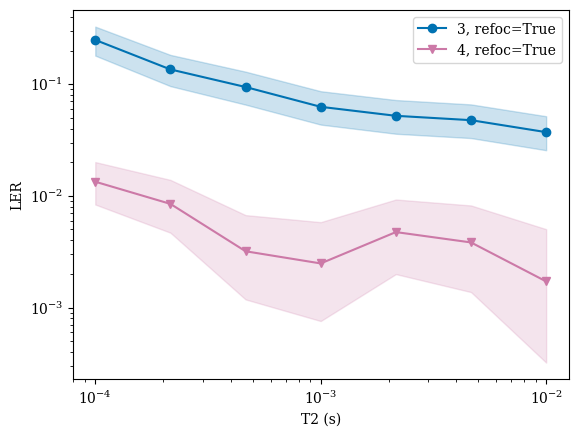

In [7]:
fig,ax = plt.subplots()

sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stats: f"{stats.json_metadata['r']}, refoc={stats.json_metadata['refoc']}",
    x_func=lambda stats: stats.json_metadata['t2'],
)

plt.loglog()
plt.legend()
plt.xlabel('T2 (s)')
plt.ylabel('LER')